# Metropolis–Hastings（MH）算法：用随机游走做采样

这份笔记用 **Markdown 先讲清直觉与公式**，再给一份 **尽量好理解、可改造的 Python 代码**。

你可以把 MH 理解为：**我想从一个目标分布 $\pi(x)$ 采样，但我只会算它的相对大小**，于是我做一个随机游走，并用“接受/拒绝”把游走修正到正确的分布上。

## 1. 采样目标：只知道比例的分布

很多时候目标分布 $\pi(x)$ 只知道到一个比例：

- $\pi(x) \propto \tilde\pi(x)$
- $\tilde\pi(x)$ 容易计算，但归一化常数 $Z=\int \tilde\pi(x)\,dx$ 很难算

例如贝叶斯里 $\pi(x)$ 可能是后验分布：$\pi(x)\propto p(\text{data}\mid x)p(x)$。

MH 的关键优点：**完全不需要 $Z$**，因为所有判断都只用到比值 $\tilde\pi(x')/\tilde\pi(x)$（或它的对数差）。

## 2. MH 的两步：提议（propose）+ 接受/拒绝（accept/reject）

假设当前状态是 $x$。MH 做两件事：

1. **提议一个新点**：从提议分布（proposal）$q(x'\mid x)$ 采样得到候选 $x'$。
2. **决定去不去**：以接受概率 $\alpha(x\to x')$ 接受 $x'$；若拒绝，则下一步仍停留在 $x$。

直觉：
- 若 $x'$ 在目标分布下更“合理”（密度更大），那就更容易接受；
- 但仍然要允许偶尔走向密度更低的地方，否则会被困在局部区域。

## 3. 关键公式：Hastings 接受率

Metropolis–Hastings 的接受概率是：

$$
\alpha(x\to x')=\min\left(1,\frac{\tilde\pi(x')\,q(x\mid x')}{\tilde\pi(x)\,q(x'\mid x)}\right).
$$

几点理解：
- 分子：走到 $x'$ 的“合理程度” $\tilde\pi(x')$，以及 **从 $x'$ 提议回 $x$ 的概率** $q(x\mid x')$；
- 分母：当前点 $x$ 的“合理程度” $\tilde\pi(x)$，以及 **从 $x$ 提议到 $x'$ 的概率** $q(x'\mid x)$。

### Metropolis 是 MH 的特例（对称提议）
如果提议是对称的：$q(x'\mid x)=q(x\mid x')$，那么 $q$ 的比值抵消，变成：

$$
\alpha(x\to x')=\min\left(1,\frac{\tilde\pi(x')}{\tilde\pi(x)}\right).
$$

## 4. 它为什么对？（细致平衡的一句话直觉）

MH 的设计让马尔可夫链的转移满足 **细致平衡（detailed balance）**：

$$
\pi(x)P(x\to x')=\pi(x')P(x'\to x),
$$

从而 $\pi$ 是这条链的不变分布（stationary distribution）。

你可以把它想成：在平衡态时，任意两点之间的“流量”对称，整体就不会偏离 $\pi$。

## 5. 实操建议（非常重要）

1. **用对数密度**：用 $\log\tilde\pi(x)$ 计算，避免 $\tilde\pi$ 极小导致下溢。
2. **调步长/尺度**：随机游走步长太小会“挪得慢”（样本强相关），太大又会“老被拒绝”。
3. **Burn-in**：丢掉前面一段迭代（链从初值“热起来”的过程）。
4. **Thinning（可选）**：隔几步取一个样本以减相关（不是必须，先学会看 trace/自相关更重要）。
5. **拒绝不是失败**：拒绝（原地不动）是保证分布正确的机制之一。

# 代码：一个通用的 Metropolis–Hastings 采样器

下面代码遵循两个原则：
- **接口直观**：你只需要提供 $\log\tilde\pi(x)$，以及“怎么提议新点”并返回提议密度（前向/后向）的对数；
- **数值稳定**：用 $\log\alpha$ 和 $\log u$ 比较，而不是直接算比值。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)


In [3]:
def metropolis_hastings(log_tilde_pi, propose, x0, n_steps, burn_in=0, thin=1):
    """Metropolis–Hastings sampler (generic).

    Parameters
    ----------
    log_tilde_pi : callable
        Function returning log unnormalized target density: log π~(x).
    propose : callable
        propose(x) -> (x_prop, log_q_forward, log_q_backward)
        where log_q_forward = log q(x_prop | x)
              log_q_backward = log q(x | x_prop)
    x0 : float or np.ndarray
        Initial state.
    n_steps : int
        Total MH transitions to run (including burn-in).
    burn_in : int
        Number of initial transitions to discard.
    thin : int
        Keep one sample every `thin` transitions after burn-in.

    Returns
    -------
    samples : np.ndarray
    accept_rate : float
    """
    if n_steps <= 0:
        raise ValueError('n_steps must be positive')
    if burn_in < 0 or burn_in >= n_steps:
        raise ValueError('burn_in must satisfy 0 <= burn_in < n_steps')
    if thin <= 0:
        raise ValueError('thin must be positive')

    x = np.array(x0, dtype=float)
    logp = float(log_tilde_pi(x))

    kept = []
    n_accept = 0

    for t in range(n_steps):
        x_prop, log_q_fwd, log_q_bwd = propose(x)
        x_prop = np.array(x_prop, dtype=float)
        logp_prop = float(log_tilde_pi(x_prop))

        # log alpha = log π~(x') - log π~(x) + log q(x|x') - log q(x'|x)
        log_alpha = (logp_prop - logp) + (log_q_bwd - log_q_fwd)
        # accept with probability min(1, exp(log_alpha))
        if np.log(rng.random()) < min(0.0, log_alpha):
            x = x_prop
            logp = logp_prop
            n_accept += 1

        if t >= burn_in and ((t - burn_in) % thin == 0):
            kept.append(x.copy())

    samples = np.stack(kept, axis=0)
    accept_rate = n_accept / n_steps
    return samples, accept_rate


## 例子 1：对称随机游走提议（Metropolis 特例）

目标分布：标准正态 $\pi(x)\propto e^{-x^2/2}$。

提议：随机游走 $x' = x + \varepsilon$，其中 $\varepsilon\sim\mathcal N(0,\sigma^2)$。这是对称提议，所以 $q$ 比值抵消。

## 例子 1 你可以这样读（把公式和代码一一对上）

这一段其实只做了 **3 件事**：

1) 目标（target）：标准正态 $\pi(x) \propto e^{-x^2/2}$，所以
$$\log \tilde\pi(x) = -\tfrac12 x^2.$$
对应代码 `log_tilde_pi_std_normal`。

2) 提议（proposal）：随机游走
$$x' = x + \varepsilon,\ \varepsilon\sim \mathcal N(0,\sigma^2).$$
对应代码 `propose_rw_normal` 里的 `x_prop = x + rng.normal(...)`。

3) 接受/拒绝：
- 先算
$$\log\alpha = \log \tilde\pi(x')-\log\tilde\pi(x) + \log q(x\mid x')-\log q(x'\mid x).$$
- 再做一次抛硬币：若 $u\sim\mathrm{Unif}(0,1)$ 且 $\log u < \min(0,\log\alpha)$，就接受 $x'$，否则留在 $x$。

### 为什么这里 `log_q_forward` 和 `log_q_backward` 都是 0？
因为这个随机游走提议是**对称的**：
$$q(x'\mid x)=\mathcal N(x,\sigma^2),\quad q(x\mid x')=\mathcal N(x',\sigma^2),$$
两者数值相等，所以
$$\log q(x\mid x')-\log q(x'\mid x)=0.$$
因此例子 1 的 MH 就退化成 Metropolis：
$$\log\alpha = -\tfrac12(x'^2-x^2).$$

### 你可以用一个具体数字检查直觉
假设当前 $x=10$，提议到 $x'=9.2$：
- $x'$ 更靠近 0，标准正态密度更大，所以 $\log\alpha>0$，基本必接收；
反过来若提议到 $x'=12$：
- 远离 0，密度更小，$\log\alpha<0$，就会以 $e^{\log\alpha}$ 的概率接受（经常拒绝）。

In [27]:
def log_tilde_pi_std_normal(x):
    # log of unnormalized N(0,1): -x^2/2 (normalizing constant not needed)
    x = np.asarray(x)
    return -0.5 * np.sum(x**2)

sigma = 1

def propose_rw_normal(x):
    # symmetric random-walk proposal: x' = x + N(0, sigma^2)
    x_prop = x + rng.normal(0.0, sigma, size=np.shape(x))
    # symmetric => log_q_forward == log_q_backward, so difference is 0
    return x_prop, 0.0, 0.0

samples, acc = metropolis_hastings(
    log_tilde_pi=log_tilde_pi_std_normal,
    propose=propose_rw_normal,
    x0=10.0,
    n_steps=20000,
    burn_in=2000,
    thin=5,
)
samples = samples.reshape(-1)
print('accept_rate =', acc)
print('mean ≈', samples.mean(), 'var ≈', samples.var())


accept_rate = 0.7033
mean ≈ -0.00693703324840113 var ≈ 1.0012402827139535


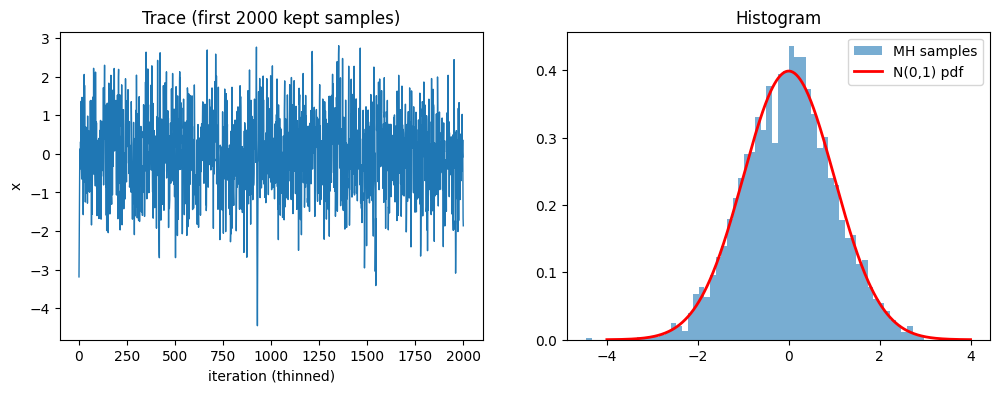

In [28]:
# Trace + histogram vs true density
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(samples[:2000], lw=1)
axes[0].set_title('Trace (first 2000 kept samples)')
axes[0].set_xlabel('iteration (thinned)')
axes[0].set_ylabel('x')

xs = np.linspace(-4, 4, 400)
true_pdf = np.exp(-0.5 * xs**2) / np.sqrt(2*np.pi)
axes[1].hist(samples, bins=60, density=True, alpha=0.6, label='MH samples')
axes[1].plot(xs, true_pdf, 'r', lw=2, label='N(0,1) pdf')
axes[1].set_title('Histogram')
axes[1].legend()
plt.show()


## 例子 2：非对称提议（必须用 Hastings 修正）

为了看清 $q$ 比值为什么必要，我们用一个 **正数域** 的例子：

- 目标分布：指数分布 $\pi(x)=e^{-x}\,\mathbf{1}_{x>0}$（同样不需要归一化常数）
- 提议分布：对数空间随机游走（log-normal RW）
  $x' = x\exp(\varepsilon)$，$\varepsilon\sim\mathcal N(0,s^2)$

这个提议在 $x$ 空间 **不对称**，所以必须用 $\alpha$ 里的 $q(x\mid x')/q(x'\mid x)$。

## 例子 2 到底“非对称”在哪里？（以及为什么一定要带上 $q$ 比值）

这段最容易卡住的点是：**同样写成“随机游走”，但在 $x$ 空间里它不是对称的**。

### 提议的定义
我们是在对数空间做随机游走：
$$x' = x\exp(\varepsilon),\ \varepsilon\sim\mathcal N(0,s^2).$$
这样永远有 $x'>0$（适合指数分布这种正数域目标）。

但注意：在 $x$ 空间里，这个提议的密度是 log-normal：
$$q(x'\mid x)=\frac{1}{x'\,s\sqrt{2\pi}}\exp\Big(-\frac{(\log x'-\log x)^2}{2s^2}\Big).$$
它前面有个 **$1/x'$ 因子**，这正是“不对称”的根源。

### Hastings 修正可以化简得非常漂亮
因为平方项是对称的：
$$(\log x'-\log x)^2 = (\log x-\log x')^2,$$
所以 $q$ 的比值只剩下 $1/x$ 那个因子：
$$\frac{q(x\mid x')}{q(x'\mid x)} = \frac{1/x}{1/x'} = \frac{x'}{x}.$$
取对数就是：
$$\log q(x\mid x') - \log q(x'\mid x) = \log\frac{x'}{x}.$$
也就是说：在例子 2 里
$$\log\alpha = (\log\tilde\pi(x')-\log\tilde\pi(x)) + \log\frac{x'}{x}.$$

这也解释了为什么代码里要显式算 `log_q_fwd` 和 `log_q_bwd`：它们并不相等。

### 一个直觉检查（不带修正会出大事）
如果你**错误地**把它当成对称提议（把 $q$ 比值丢掉），那么链会倾向于偏向某些尺度（因为提议在乘法尺度上更“自然”），采出来的就不是目标指数分布了。Hastings 修正就是用 $q(x\mid x')/q(x'\mid x)$ 把这种偏差抵消掉。

In [6]:
def log_tilde_pi_exponential(x):
    x = float(np.asarray(x))
    if x <= 0.0:
        return -np.inf
    return -x  # log(e^{-x})

s = 0.6  # proposal scale in log-space

def log_lognormal_pdf(x_new, x_old, s):
    """log q(x_new | x_old) for x_new>0 given x_old>0 with lognormal RW."""
    if x_new <= 0.0 or x_old <= 0.0:
        return -np.inf
    # If log(x_new) ~ N(log(x_old), s^2), then density in x_new has 1/x_new factor
    z = (np.log(x_new) - np.log(x_old)) / s
    return -0.5 * z**2 - np.log(x_new * s * np.sqrt(2*np.pi))

def propose_rw_lognormal(x):
    x = float(np.asarray(x))
    eps = rng.normal(0.0, s)
    x_prop = x * np.exp(eps)
    log_q_fwd = log_lognormal_pdf(x_prop, x, s)
    log_q_bwd = log_lognormal_pdf(x, x_prop, s)
    return x_prop, log_q_fwd, log_q_bwd

samples2, acc2 = metropolis_hastings(
    log_tilde_pi=log_tilde_pi_exponential,
    propose=propose_rw_lognormal,
    x0=1.0,
    n_steps=30000,
    burn_in=3000,
    thin=10,
)
samples2 = samples2.reshape(-1)
print('accept_rate =', acc2)
print('mean (true=1) ≈', samples2.mean())


accept_rate = 0.829
mean (true=1) ≈ 0.975340942563525


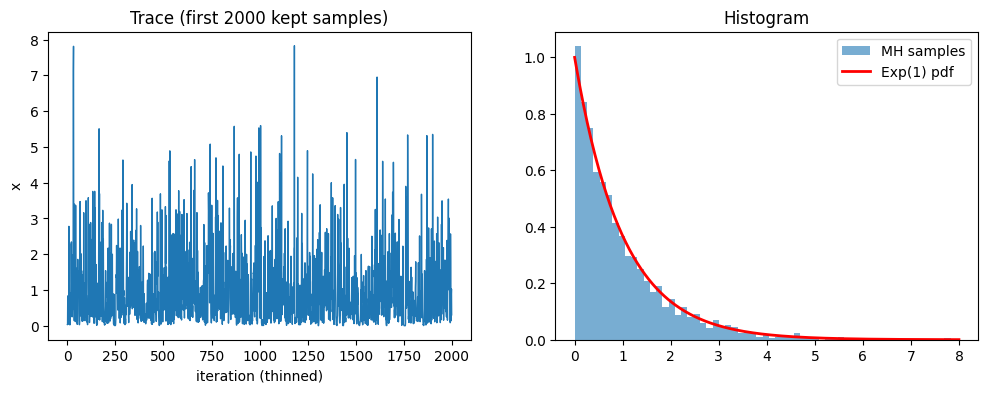

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(samples2[:2000], lw=1)
axes[0].set_title('Trace (first 2000 kept samples)')
axes[0].set_xlabel('iteration (thinned)')
axes[0].set_ylabel('x')

xs = np.linspace(0, 8, 400)
true_pdf = np.exp(-xs)
axes[1].hist(samples2, bins=60, density=True, alpha=0.6, label='MH samples')
axes[1].plot(xs, true_pdf, 'r', lw=2, label='Exp(1) pdf')
axes[1].set_title('Histogram')
axes[1].legend()
plt.show()


# 小练习（建议你动手改）

1. 在例子 1 里把 $\sigma$ 改成 $0.1, 0.5, 2.0, 5.0$，观察接受率、trace 相关性有什么变化。
2. 把目标分布改成双峰：$\pi(x)\propto 0.5\,e^{-(x-3)^2/2}+0.5\,e^{-(x+3)^2/2}$，看看随机游走 MH 是否容易在单峰附近“卡住”。
3. 把状态从 1 维改成 2 维向量 $x\in\mathbb R^2$（代码已经支持向量），目标取二维正态，画出散点图看看形状。

sigma = 1
accept_rate = 0.7136333333333333
P(sample>0) ≈ 0.5489090909090909


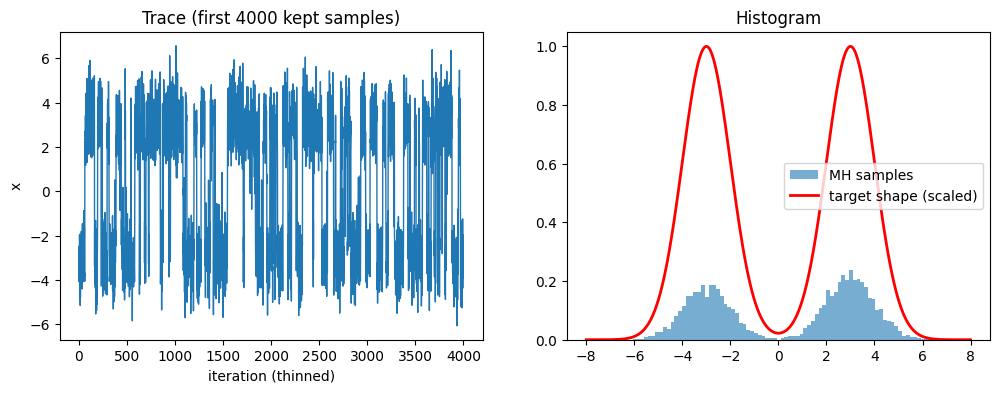

提示：把 sigma 调大（如 1.5 或 2.5）再跑一次，通常更容易在两个峰之间来回跳。


In [84]:
# 小练习 2：双峰目标（随机游走 MH 是否会卡在单峰附近？）
import numpy as np
import matplotlib.pyplot as plt

# 为了复现实验结果，这里重置随机数发生器
# rng = np.random.default_rng(0)

def log_tilde_pi_bimodal(x):
    """log π~(x) for a symmetric bimodal mixture of two unit-variance Gaussians."""
    x = float(np.asarray(x))
    # π(x) ∝ 0.5 exp(-(x-3)^2/2) + 0.5 exp(-(x+3)^2/2)
    a = np.log(0.5) - 0.5 * (x - 3.0) ** 2
    b = np.log(0.5) - 0.5 * (x + 3.0) ** 2
    return np.logaddexp(a, b)  # stable log-sum-exp

sigma = 1  # 小步长：通常更容易“卡在某一个峰”
def propose_rw_normal_1d(x):
    x = float(np.asarray(x))
    x_prop = x + rng.normal(0.0, sigma)
    return x_prop, 0.0, 0.0  # 对称提议

samples_bi, acc_bi = metropolis_hastings(
    log_tilde_pi=log_tilde_pi_bimodal,
    propose=propose_rw_normal_1d,
    x0=-3.0,
    n_steps=60000,
    burn_in=5000,
    thin=10,
 )
samples_bi = samples_bi.reshape(-1)

print('sigma =', sigma)
print('accept_rate =', acc_bi)
print('P(sample>0) ≈', np.mean(samples_bi > 0.0))  # 两个峰对称时，理想值应接近 0.5（若混合得好）

# 画图：trace + 直方图（叠加真实目标密度形状，未归一化也没关系）
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(samples_bi[:4000], lw=1)
axes[0].set_title('Trace (first 4000 kept samples)')
axes[0].set_xlabel('iteration (thinned)')
axes[0].set_ylabel('x')

xs = np.linspace(-8, 8, 800)
unnorm = 0.5 * np.exp(-0.5 * (xs - 3.0) ** 2) + 0.5 * np.exp(-0.5 * (xs + 3.0) ** 2)
# 归一化到“最大值为 1”只是为了叠加形状方便
unnorm = unnorm / unnorm.max()
axes[1].hist(samples_bi, bins=80, density=True, alpha=0.6, label='MH samples')
axes[1].plot(xs, unnorm, 'r', lw=2, label='target shape (scaled)')
axes[1].set_title('Histogram')
axes[1].legend()
plt.show()

print('提示：把 sigma 调大（如 1.5 或 2.5）再跑一次，通常更容易在两个峰之间来回跳。')

accept_rate = 0.44212


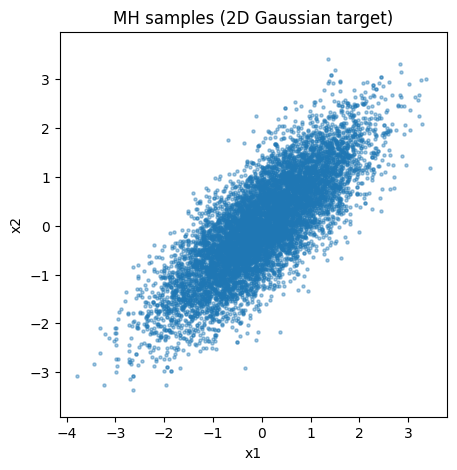

In [66]:
# 小练习 3：把状态改成 2 维向量，目标取二维正态，画散点图
import numpy as np
import matplotlib.pyplot as plt

# rng = np.random.default_rng(1)

# 目标：二维正态（这里给一个相关的协方差，散点会更有“椭圆”形状）
Sigma = np.array([[1.0, 0.8],[0.8, 1.0]])
Sigma_inv = np.linalg.inv(Sigma)

def log_tilde_pi_gaussian_2d(x):
    x = np.asarray(x, dtype=float).reshape(2)
    return -0.5 * float(x.T @ Sigma_inv @ x)  # 忽略常数项

sigma2 = 0.9
def propose_rw_normal_2d(x):
    x = np.asarray(x, dtype=float).reshape(2)
    x_prop = x + rng.normal(0.0, sigma2, size=2)
    return x_prop, 0.0, 0.0  # 对称提议

samples_2d, acc_2d = metropolis_hastings(
    log_tilde_pi=log_tilde_pi_gaussian_2d,
    propose=propose_rw_normal_2d,
    x0=np.array([5.0, -5.0]),
    n_steps=50000,
    burn_in=5000,
    thin=5,
 )

print('accept_rate =', acc_2d)

pts = samples_2d  # shape: (n_kept, 2)
plt.figure(figsize=(5, 5))
plt.scatter(pts[:, 0], pts[:, 1], s=5, alpha=0.4)
plt.title('MH samples (2D Gaussian target)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.show()